# Phase 4: Model Building
Goal: Train multiple classifiers, compare performance, and select the best model.

In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(X_train.shape, X_test.shape)

(1760, 7) (440, 7)


In [3]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42),
    'Naive Bayes': GaussianNB()
}

In [4]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9727
Decision Tree: 0.9795
Random Forest: 0.9955
KNN: 0.9795
SVM: 0.9841
Naive Bayes: 0.9955


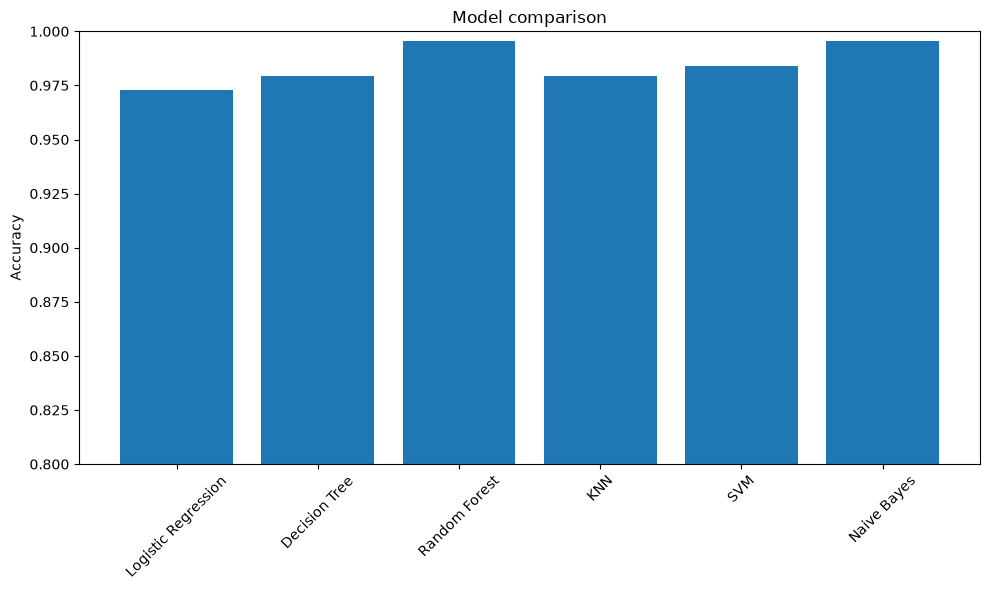

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values())
plt.ylabel('Accuracy')
plt.title('Model comparison')
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png')
plt.show()

In [6]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"Best model: {best_model_name} ({results[best_model_name]:.4f})")

preds = best_model.predict(X_test)
print(classification_report(y_test, preds))

Best model: Random Forest (0.9955)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00   

## Summary
- Models compared: Logistic Regression, Decision Tree, Random Forest, KNN, SVM, Naive Bayes.
- Accuracy scores: Logistic Regression 0.9727, Decision Tree 0.9795, Random Forest 0.9955, KNN 0.9795, SVM 0.9841, Naive Bayes 0.9955.
- Best performing model: Random Forest, with 0.9955 accuracy (tied with Naive Bayes).
- Precision/recall for Random Forest: near-perfect across all 22 crop classes; only minor confusion on classes 2, 8, 11, and 20 (precision/recall of 0.95 instead of 1.00), all other classes scored perfect 1.00 precision and recall.
- Weighted average precision, recall, and f1-score: 1.00 across 440 test samples.

## Bonus: K-Means Clustering Analysis
Exploring whether unsupervised clustering naturally groups crops by their environmental profile, independent of the known labels.

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Cluster into 22 groups (matching the number of actual crop types) to see if clusters align with real labels
kmeans = KMeans(n_clusters=22, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_train)

# Compare clusters against true labels using Adjusted Rand Index
# (measures how well clustering matches true groupings, 1.0 = perfect match, 0 = random)
ari_score = adjusted_rand_score(y_train, cluster_labels)
print(f"Adjusted Rand Index (cluster alignment with true crop labels): {ari_score:.4f}")

Adjusted Rand Index (cluster alignment with true crop labels): 0.6486


## Clustering Summary
- Adjusted Rand Index: 0.6486
- Interpretation: K-Means clustering (unsupervised) was explored to check whether crops naturally group by N/P/K/climate profile without label information. An ARI of 0.6486 indicates a moderately strong natural grouping — crops do tend to cluster by their environmental signature, but not perfectly, since some crops with similar growing conditions (e.g. blackgram and lentil, both legumes with overlapping nutrient needs) are harder to separate using distance alone.
- Random Forest remains the production model for this project, since it uses label information to draw sharper decision boundaries and achieves 99.55% accuracy, well above what unsupervised clustering alone can offer.